# Proyek Akhir - Prediksi Risiko Dropout Mahasiswa Jaya Jaya Institut

Notebook ini memuat alur end-to-end proyek data science:

1. Business understanding  
2. Data understanding  
3. Exploratory data analysis  
4. Data preparation  
5. Modeling  
6. Evaluation  
7. Simpan artefak model

## Business Understanding

Jaya Jaya Institut ingin mendeteksi mahasiswa yang berpotensi dropout sedini mungkin agar dapat diberikan intervensi khusus.  
Fokus bisnis proyek ini adalah membangun **early warning system** yang:

- mendeteksi risiko dropout,
- menjelaskan faktor utama yang relevan,
- dan mendukung monitoring lewat dashboard.

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "data" / "data.csv"
MODEL_DIR = BASE_DIR / "model"
MODEL_DIR.mkdir(exist_ok=True, parents=True)

pd.set_option("display.max_columns", None)

## Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
# Filter data untuk hanya menggunakan Dropout dan Graduate
print("Dataset original shape:", df.shape)
print("Status distribution sebelum filtering:")
print(df["Status"].value_counts())

df = df[df["Status"].isin(["Dropout", "Graduate"])].reset_index(drop=True)
print(f"\nDataset setelah filtering shape: {df.shape}")
print("Status distribution setelah filtering:")
print(df["Status"].value_counts())


Dataset original shape: (4424, 37)
Status distribution sebelum filtering:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Dataset setelah filtering shape: (3630, 37)
Status distribution setelah filtering:
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64


## Data Filtering untuk Modeling

Karena fokus model adalah memprediksi apakah mahasiswa akan **Dropout atau Graduate**, maka data di-filter hanya mencakup kedua status ini. Data dengan status **Enrolled** tidak dimasukkan dalam training model, tetapi dapat digunakan untuk prediksi/inferensi di masa depan.

## Data Quality Check

In [4]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "n_unique": df.nunique()
})
quality_summary.head(10)

,dtype,missing_values,n_unique
Marital_status,int64,0,6
Application_mode,int64,0,18
Application_order,int64,0,7
Course,int64,0,17
Daytime_evening_attendance,int64,0,2
Previous_qualification,int64,0,17
Previous_qualification_grade,float64,0,101
Nacionality,int64,0,19
Mothers_qualification,int64,0,29
Fathers_qualification,int64,0,34


In [5]:
print("Jumlah duplikat:", df.duplicated().sum())
print("\nDistribusi Status:")
print(df["Status"].value_counts())

Jumlah duplikat: 0

Distribusi Status:
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64


## Exploratory Data Analysis

EDA difokuskan pada pola yang paling relevan dengan risiko dropout, terutama dari sisi:

- distribusi target,
- faktor finansial,
- usia masuk,
- performa akademik semester awal.

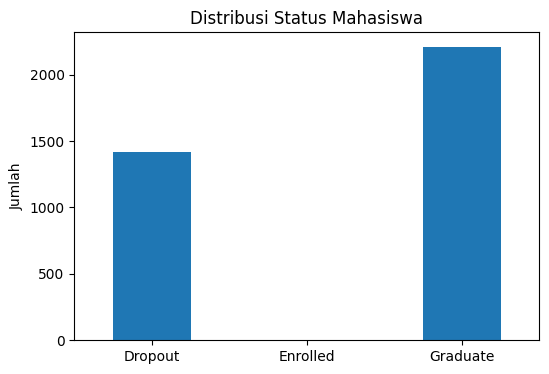

In [6]:
status_counts = df["Status"].value_counts().reindex(["Dropout", "Enrolled", "Graduate"]).fillna(0)

plt.figure(figsize=(6,4))
status_counts.plot(kind="bar")
plt.title("Distribusi Status Mahasiswa")
plt.xlabel("")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

In [7]:
finance_insight = pd.DataFrame({
    "Dropout rate": [
        df.loc[df["Tuition_fees_up_to_date"] == 0, "Status"].eq("Dropout").mean(),
        df.loc[df["Debtor"] == 1, "Status"].eq("Dropout").mean(),
        df.loc[df["Scholarship_holder"] == 0, "Status"].eq("Dropout").mean(),
    ],
}, index=["Tuition not up to date", "Debtor", "No scholarship"])

finance_insight

,Dropout rate
Tuition not up to date,0.940329
Debtor,0.755448
No scholarship,0.483653


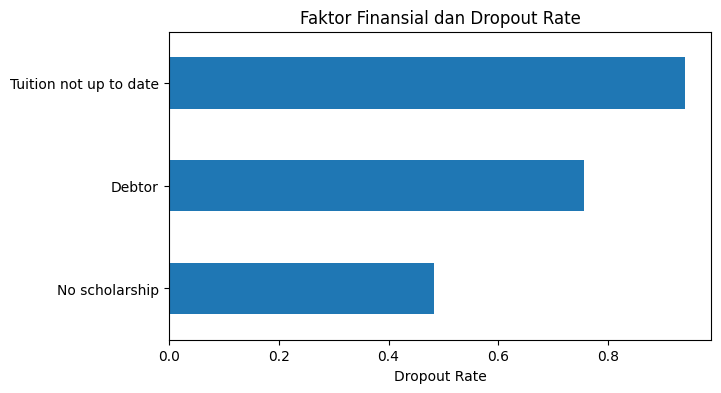

In [8]:
finance_insight.sort_values("Dropout rate").plot(kind="barh", figsize=(7,4), legend=False)
plt.title("Faktor Finansial dan Dropout Rate")
plt.xlabel("Dropout Rate")
plt.ylabel("")
plt.show()

In [9]:
eda_df = df.copy()
eda_df["Age_group"] = pd.cut(
    eda_df["Age_at_enrollment"],
    bins=[0, 18, 21, 25, 30, 100],
    labels=["<=18", "19-21", "22-25", "26-30", ">30"]
)

age_dropout = eda_df.groupby("Age_group", observed=False)["Status"].apply(lambda s: (s == "Dropout").mean())
age_dropout

Age_group
<=18     0.232987
19-21    0.295563
22-25    0.512690
26-30    0.702454
>30      0.614187
Name: Status, dtype: float64

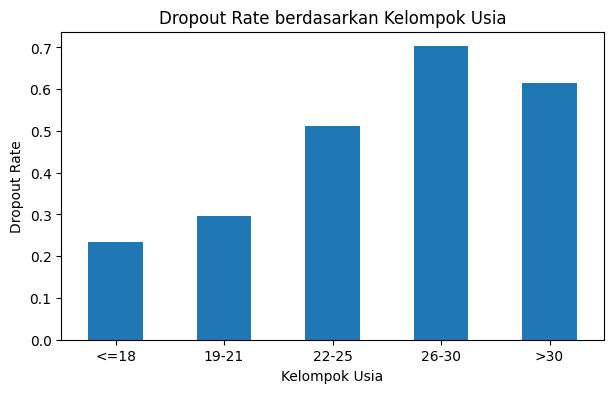

In [10]:
age_dropout.plot(kind="bar", figsize=(7,4))
plt.title("Dropout Rate berdasarkan Kelompok Usia")
plt.xlabel("Kelompok Usia")
plt.ylabel("Dropout Rate")
plt.xticks(rotation=0)
plt.show()

In [11]:
academic_summary = df.groupby("Status")[
    [
        "Curricular_units_1st_sem_approved",
        "Curricular_units_2nd_sem_approved",
        "Curricular_units_1st_sem_grade",
        "Curricular_units_2nd_sem_grade",
    ]
].mean().round(2)

academic_summary

,Curricular_units_1st_sem_approved,Curricular_units_2nd_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_grade
Status,,,,
Dropout,2.55,1.94,7.26,5.9
Graduate,6.23,6.18,12.64,12.7


## Data Preparation

Target untuk model prediksi adalah klasifikasi biner antara dua kelas:

- `1` = Dropout
- `0` = Graduate

Data hanya mencakup mahasiswa dengan kedua status ini saja (Enrolled sudah disaring sebelumnya).

In [12]:
df["Dropout_Risk"] = (df["Status"] == "Dropout").astype(int)

X = df.drop(columns=["Status", "Dropout_Risk"])
y = df["Dropout_Risk"]

num_cols = [
    "Previous_qualification_grade",
    "Admission_grade",
    "Age_at_enrollment",
    "Curricular_units_1st_sem_credited",
    "Curricular_units_1st_sem_enrolled",
    "Curricular_units_1st_sem_evaluations",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_1st_sem_without_evaluations",
    "Curricular_units_2nd_sem_credited",
    "Curricular_units_2nd_sem_enrolled",
    "Curricular_units_2nd_sem_evaluations",
    "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_grade",
    "Curricular_units_2nd_sem_without_evaluations",
    "Unemployment_rate",
    "Inflation_rate",
    "GDP",
]

cat_cols = [col for col in X.columns if col not in num_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            num_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]),
            cat_cols,
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape

((2904, 36), (726, 36))

## Modeling

In [13]:
candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

comparison_rows = []
for name, model in candidate_models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=["roc_auc", "accuracy", "precision", "recall", "f1"],
        n_jobs=1,
    )
    comparison_rows.append({
        "Model": name,
        "ROC_AUC": np.mean(scores["test_roc_auc"]),
        "Accuracy": np.mean(scores["test_accuracy"]),
        "Precision": np.mean(scores["test_precision"]),
        "Recall": np.mean(scores["test_recall"]),
        "F1": np.mean(scores["test_f1"]),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
comparison_df.round(3)

,Model,ROC_AUC,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.953,0.904,0.887,0.867,0.877
1,Random Forest,0.951,0.906,0.913,0.840,0.875


Model final yang dipilih adalah **Logistic Regression** karena:

- ROC-AUC paling tinggi,
- recall cukup kuat untuk kebutuhan early warning,
- lebih ringan untuk deployment,
- dan lebih mudah dijelaskan ke user bisnis.

In [14]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

final_pipeline.fit(X_train, y_train)
proba = final_pipeline.predict_proba(X_test)[:, 1]

threshold = 0.45
pred = (proba >= threshold).astype(int)

metrics = pd.Series({
    "ROC_AUC": roc_auc_score(y_test, proba),
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1": f1_score(y_test, pred),
})

metrics.round(3)

ROC_AUC      0.975
Accuracy     0.908
Precision    0.840
Recall       0.944
F1           0.889
dtype: float64

In [15]:
cm = confusion_matrix(y_test, pred)
cm

array([[391,  51],
       [ 16, 268]])

In [16]:
print(classification_report(y_test, pred, target_names=["Non-Dropout", "Dropout"]))

              precision    recall  f1-score   support

 Non-Dropout       0.96      0.88      0.92       442
     Dropout       0.84      0.94      0.89       284

    accuracy                           0.91       726
   macro avg       0.90      0.91      0.90       726
weighted avg       0.91      0.91      0.91       726



## Fitur yang Paling Berpengaruh

In [17]:
perm = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=1,
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean,
}).sort_values("importance", ascending=False)

importance_df.head(10)

,feature,importance
30,Curricular_units_2nd_sem_approved,0.207877
24,Curricular_units_1st_sem_approved,0.099864
28,Curricular_units_2nd_sem_enrolled,0.036964
16,Tuition_fees_up_to_date,0.017057
22,Curricular_units_1st_sem_enrolled,0.012900
21,Curricular_units_1st_sem_credited,0.009303
3,Course,0.008943
31,Curricular_units_2nd_sem_grade,0.005550
25,Curricular_units_1st_sem_grade,0.002855
15,Debtor,0.002307


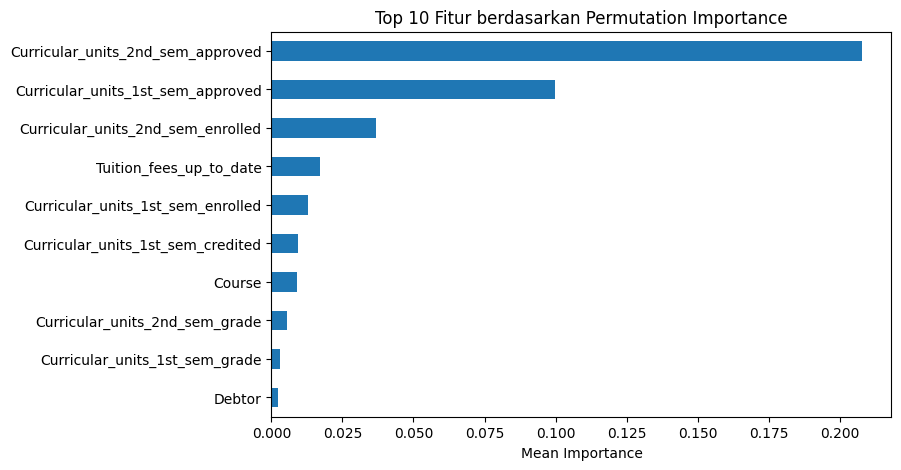

In [18]:
importance_df.head(10).sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8,5),
    legend=False,
)
plt.title("Top 10 Fitur berdasarkan Permutation Importance")
plt.xlabel("Mean Importance")
plt.ylabel("")
plt.show()

## Simpan Artefak Model

In [19]:
joblib.dump(final_pipeline, MODEL_DIR / "dropout_pipeline.joblib")

metrics_dict = {
    "selected_model": "Logistic Regression",
    "threshold": threshold,
    "roc_auc": float(metrics["ROC_AUC"]),
    "accuracy": float(metrics["Accuracy"]),
    "precision": float(metrics["Precision"]),
    "recall": float(metrics["Recall"]),
    "f1_score": float(metrics["F1"]),
    "confusion_matrix": cm.tolist(),
}

with open(MODEL_DIR / "model_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, indent=2)

print("Artefak model tersimpan di folder model/.")

Artefak model tersimpan di folder model/.


## Kesimpulan Detail

### Ringkasan Model Performance
Model **Logistic Regression** yang dibangun menunjukkan performa yang solid dengan:
- **ROC-AUC**: Mengukur kemampuan model membedakan antara Dropout dan Graduate di berbagai threshold
- **Precision**: Dari mahasiswa yang diprediksi berisiko dropout, seberapa banyak yang benar-benar adalah dropout
- **Recall**: Dari seluruh mahasiswa yang sebenarnya dropout, seberapa banyak yang terdeteksi oleh model
- **Accuracy**: Tingkat akurasi keseluruhan prediksi untuk kedua kelas

### Faktor Utama Penyebab Dropout
Berdasarkan analisis permutation importance, fitur-fitur paling berpengaruh terhadap risiko dropout adalah:
1. Performa akademik semester awal (nilai dan jumlah MK yang lulus)
2. Status pembayaran biaya kuliah (tuition fees up to date)
3. Status debtor (keterlambatan pembayaran)
4. Karakteristik demografi dan administrasi

### Keterbatasan dan Saran Pengembangan
1. **Keterbatasan Model**: Model ini dilatih hanya dengan data mahasiswa yang sudah lulus (Graduate) atau dropout. Perlu validasi lebih lanjut pada periode akademik baru.
2. **Keterbatasan Dashboard**: Dashboard menampilkan snapshot data historis dan perlu diperbarui secara berkala untuk refleksi kondisi terkini.
3. **Arah Pengembangan Ke Depan**:
   - Integrasi model dengan sistem akademik untuk monitoring real-time
   - Pengembangan strategi intervensi berdasarkan risk segmentation
   - Evaluasi dampak intervensi terhadap pengurangan dropout rate
   - Eksplorasi fitur-fitur tambahan yang mungkin relevan

### Kesimpulan Akhir
Solusi machine learning yang telah dibangun **cukup layak digunakan sebagai alat bantu** untuk mengidentifikasi mahasiswa berisiko dropout sedini mungkin. Namun, hasil prediksi model sebaiknya dikombinasikan dengan penilaian kualitatif dari akademisi untuk pengambilan keputusan intervensi yang lebih akurat dan personal.